# Student Performance Data Analysis Dashboard

## Overview
This project analyzes a student performance dataset using Pandas, Matplotlib, and Seaborn. The objective is to clean the data, create new features, visualize important patterns, and summarize key insights.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style("whitegrid")

# Data Preparation

In [3]:
df = pd.read_csv("student_performance.csv")

df.head()

,StudentID,StudyHours,Attendance,SleepHours,ExamScore
0,1,6.8,61,7.7,85
1,2,3.0,66,7.4,65
2,3,1.8,87,4.2,40
3,4,3.0,92,7.0,72
4,5,2.8,94,6.1,66


In [4]:
df.info()

print("\nMissing Values")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   StudentID   200 non-null    int64  
 1   StudyHours  200 non-null    float64
 2   Attendance  200 non-null    int64  
 3   SleepHours  200 non-null    float64
 4   ExamScore   200 non-null    int64  
dtypes: float64(2), int64(3)
memory usage: 7.9 KB

Missing Values
StudentID     0
StudyHours    0
Attendance    0
SleepHours    0
ExamScore     0
dtype: int64


# Study Category



In [5]:

df["StudyCategory"] = pd.cut(
    df["StudyHours"],
    bins=[0,3,6,10],
    labels=["Low","Medium","High"]
)

df["Result"] = np.where(df["ExamScore"]>=50,"Pass","Fail")

df.head()

,StudentID,StudyHours,Attendance,SleepHours,ExamScore,StudyCategory,Result
0,1,6.8,61,7.7,85,High,Pass
1,2,3.0,66,7.4,65,Low,Pass
2,3,1.8,87,4.2,40,Low,Fail
3,4,3.0,92,7.0,72,Low,Pass
4,5,2.8,94,6.1,66,Low,Pass


# Visualizations

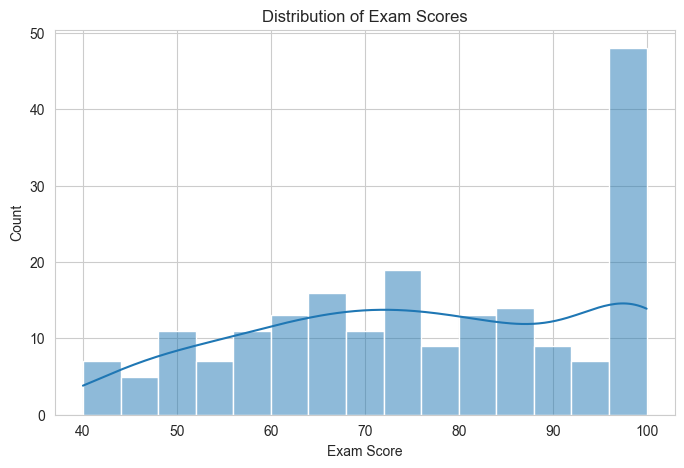

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(df["ExamScore"], bins=15, kde=True)

plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Count")

plt.show()

### Insight
Most students scored between the middle score range. The histogram helps identify the overall distribution of exam performance.

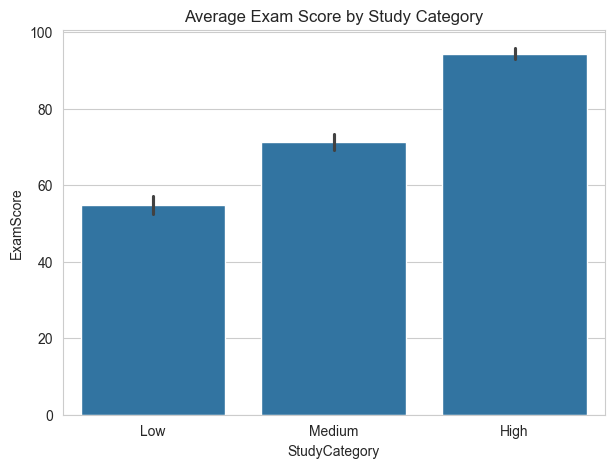

In [7]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=df,
    x="StudyCategory",
    y="ExamScore"
)

plt.title("Average Exam Score by Study Category")

plt.show()

### Insight
Students who study more hours generally achieve higher average exam scores.

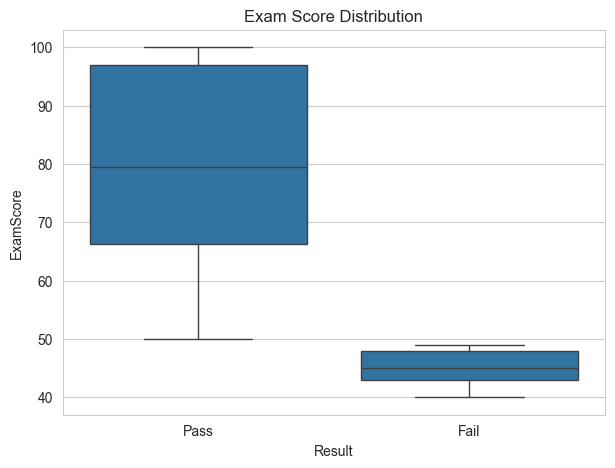

In [9]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="Result",
    y="ExamScore"
)

plt.title("Exam Score Distribution")

plt.show()

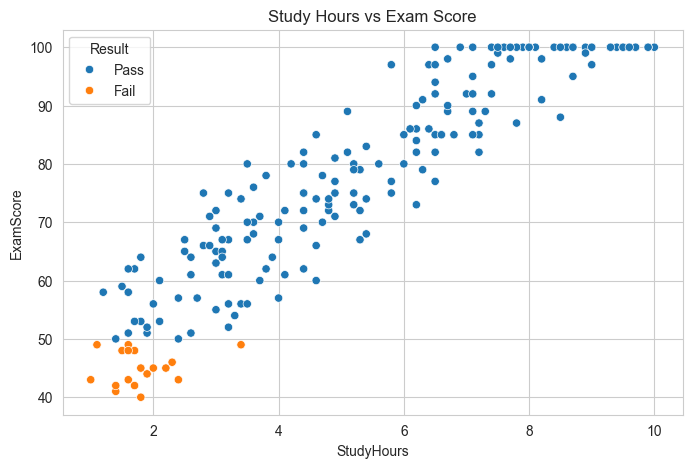

In [10]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="StudyHours",
    y="ExamScore",
    hue="Result"
)

plt.title("Study Hours vs Exam Score")

plt.show()

### Insight
Students who spend more time studying tend to obtain higher exam scores.

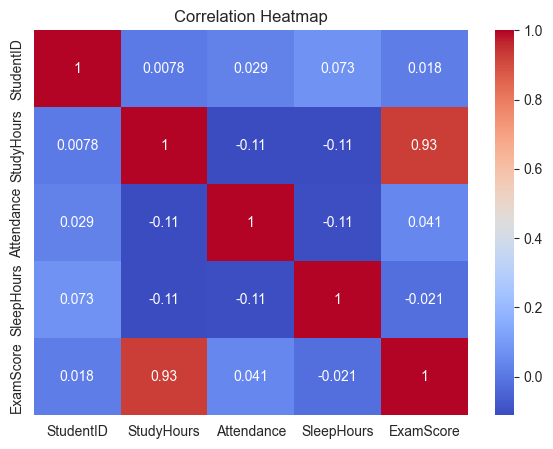

In [12]:
plt.figure(figsize=(7,5))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

### Insight
Study hours and attendance show positive relationships with exam scores. The heatmap highlights correlations among numerical variables.
# Conclusion

- Data was cleaned and inspected.
- Two new features were created:
  - StudyCategory
  - Result (Pass/Fail)
- Five different visualizations were produced.
- Students with higher study hours generally achieved better exam scores.
- Attendance also positively influenced performance.